In [2]:
# Demo, Hello World! for quantum computing. This is the first pre-class reading that prompted me to 
# try out several different Qiskit features for creating circuits.

from qiskit import QuantumCircuit # our class representing circuits
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService # connect to IBM
from qiskit_ibm_runtime import SamplerV2 as Sampler # execute circuits, sample results
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

circuit = QuantumCircuit(3, 3) # circuit with 2 qubits and 2 classical bits for storing measurements
circuit.x(1)  # Apply X gate on qubit 1, equivalent to NOT, state 0 to 1 and so on
circuit.x(2)

circuit.h(0)  # Apply H gate on qubit 0, Hadamard gate, creates a superposition
circuit.h(1)  # Apply H gate on qubit 1
circuit.h(2)

# Apply CX gate with control qubit 0 and target qubit 1
circuit.cx(0, 1) # if qubit 0 is state 1, qubit 1 flips

circuit.h(0)  # Apply H gate on qubit 0, again
circuit.h(1)  # Apply H gate on qubit 1
circuit.h(2)

# Measure qubit 0 and store result in classical bit 0
circuit.measure(0, 0)

# Measure qubit 1 and store result in classical bit 1
circuit.measure(1, 1)

circuit.measure(2, 2)

# Visualize the circuit
circuit.draw('mpl', idle_wires=False, scale=3)

# Run the circuit on a simulator
simulator = AerSimulator()
job = simulator.run(circuit, shots=1000)
result = job.result()
counts = result.get_counts()

print(counts)

# experimentation
# original: 11 : 1000
# no x-gate: 00 : 1000
# cx is after all other gates, or before all other gates: 10 : 1000
# putting cx in between superposition times happening seems to influence result?
# 3-qubit attempt: 111 : 1000

{'111': 1000}


IBM Quantum service loaded successfully.


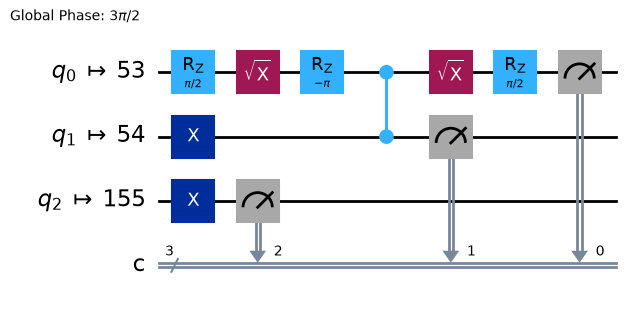

In [3]:
# optimize for backend before going into hardware!
from qiskit_ibm_runtime import QiskitRuntimeService

# Run this once in a trusted personal environment.
# Replace the placeholders with your own IBM Quantum Platform credentials.
# SAVE_ACCOUNT STEP DATA HIDDEN

# Later, load the saved default account like this:
service = QiskitRuntimeService()
print("IBM Quantum service loaded successfully.")

backend = service.least_busy(
    simulator=False,
    operational=True
)

# create transpilation pipeline to fit circuit with backend
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)

isa_circuit = pm.run(circuit)
isa_circuit.draw('mpl', idle_wires=False) # draw the optimized version of our circuit

In [5]:
# execute circuit by sending a job.
sampler = Sampler(backend)
job = sampler.run([isa_circuit])
result = job.result()

databin = result[0].data

bitstrings = databin.c.get_bitstrings()
counts = databin.c.get_counts()

print(bitstrings)
print(counts)

['111', '111', '111', '111', '111', '110', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '011', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '100', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '110', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111', '111'

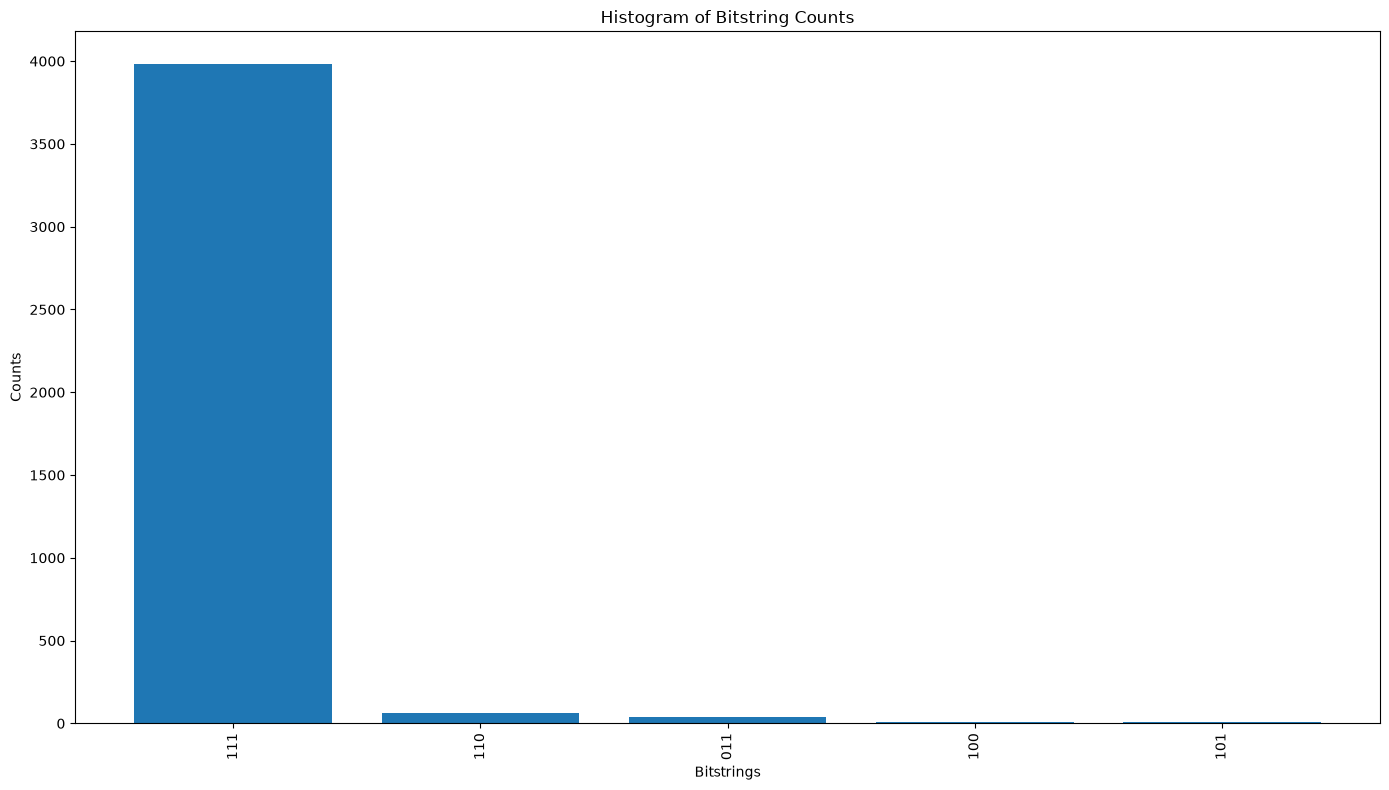

In [6]:
# graph our retrieved results
import matplotlib.pyplot as plt

count_values = [counts[bitstring] for bitstring in bitstrings]

plt.figure(figsize=(14, 8))
plt.bar(bitstrings, count_values)
plt.xlabel('Bitstrings')
plt.ylabel('Counts')
plt.title('Histogram of Bitstring Counts')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()